# Allman latent-class MNAR simulation

## tl;dr

This notebook separates observed-law recovery from latent decomposition. For the observed-law results, the proposed estimator is the direct Stage-1 saturated bridge. We report parameter-specific bias, empirical Monte Carlo standard deviation (SD), mean estimated standard error (SE), and 95% Wald coverage for population outcome marginals and every supported-block cell. The full three-item joint law and the latent parameters are retained as Stage-2 diagnostics.

## Model

Allman, Matias and Rhodes (2009, Section 3) define the $r$-class, $p$-feature model $M(r;\kappa_1,\ldots,\kappa_p)$. Their conditional-independence statement is: “conditional on $Z$, the $X_j$'s are independent random variables.” In their notation,

$$
P_i=\bigotimes_{j=1}^p p_{ij},\qquad
P=\sum_{i=1}^r \pi_iP_i.
$$

We use exactly this model class with $r=2$, $p=4$, and binary observed features $(W,Y_1,Y_2,Y_3)$. The latent class is denoted by $F$ in our paper. Since $p=4$ and $r=2$, the Bernoulli-product model satisfies the generic-identification bound in Allman et al. (2009, Corollary 5).

### What can and cannot be reproduced

The model definition and identification condition above come directly from Allman et al. The paper does not specify a numerical DGP, sample size, optimizer, bias, RMSE, standard error, or coverage result. Therefore the complete-data oracle below is our reproducibility benchmark; there is no Allman Monte Carlo table to match.

## Setup

The latent-parameter comparison uses the following five model fits:

1. full_data_oracle: full product-mixture likelihood before missingness.
2. mar: observed-data FIML using every observed item under ignorability.
3. selection_likelihood_correct: likelihood for $(W,Y_{obs},R)$ with the true selection interaction, integrating over latent classes and missing items while deliberately discarding the shadow $Z$.
4. selection_likelihood_misspecified: the same likelihood with the Y1 main effect and interaction omitted while retaining MNAR dependence on Yj.
5. proposed_saturated_bridge: ridge-regularized, constrained inverse bridge followed by bridge-weighted pairwise latent-model fitting.

For observed-law inference, the first four estimates are the laws implied by their fitted models, whereas the proposed estimate is taken immediately after Stage 1 as proposed_stage1_bridge. Likelihood-based SEs use a delta-method sandwich covariance based on the observed likelihood. Proposed Stage-1 SEs use a nonparametric bootstrap that resamples observations and re-estimates both block bridges.

The true selection intercepts are calibrated once from the population distribution. The shadow has a full-rank $4\times4$ conditional probability matrix over pair-outcome cells, so finite categorical B-completeness is built into the DGP.

In [1]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "simulation":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from simulation.latent_mnar_sim import (
    binary_product_mixture_joint, load_config, run_simulation,
)

CONFIG_PATH = ROOT / "simulation" / "config.yml"
config = load_config(CONFIG_PATH)
print(config["model"]["name"])
print(f"n={config['sample_size']}, replications={config['replications']}")

M(r; kappa_1, ..., kappa_p)
n=500, replications=100


## Simulation

In [2]:
(
    summary,
    overlap,
    bridge_diagnostics,
    replication_results,
    y_summary,
    y_pair_distribution,
    observed_law_inference_raw,
    observed_law_inference_summary,
) = run_simulation(config)
results_dir = ROOT / "simulation" / "results"
results_dir.mkdir(exist_ok=True)
summary.to_csv(results_dir / "allman_summary.csv", index=False)
overlap.to_csv(results_dir / "allman_overlap.csv", index=False)
bridge_diagnostics.to_csv(results_dir / "allman_bridge_diagnostics.csv", index=False)
replication_results.to_csv(results_dir / "allman_replication_results.csv", index=False)
y_summary.to_csv(results_dir / "allman_y_marginal_summary.csv", index=False)
y_pair_distribution.to_csv(results_dir / "allman_y_pair_distribution.csv", index=False)
observed_law_inference_raw.to_csv(
    results_dir / "allman_observed_law_inference_raw.csv", index=False
)
observed_law_inference_summary.to_csv(
    results_dir / "allman_observed_law_inference_summary.csv", index=False
)
summary.round(4)

,method,M_bias,M_mean_absolute_error,p_f1_bias,mean_iterations,convergence_rate,M_RMSE,p_f1_RMSE,M_bias_MCSE,M_RMSE_MCSE,p_f1_bias_MCSE,p_f1_RMSE_MCSE
0,full_data_oracle,0.0031,0.0279,-0.0019,27.11,1.0,0.0351,0.0361,0.0019,0.0011,0.0036,0.0025
1,mar,-0.0496,0.0734,-0.0193,47.62,1.0,0.0966,0.0572,0.0028,0.0025,0.0054,0.0041
2,proposed_saturated_bridge,-0.0064,0.0436,-0.0029,44.96,1.0,0.0555,0.0517,0.0028,0.0019,0.0052,0.0040
3,selection_likelihood_correct,-0.0008,0.0415,0.0008,184.21,1.0,0.0544,0.0427,0.0027,0.0025,0.0043,0.0034
4,selection_likelihood_misspecified,0.0409,0.0552,0.0092,124.24,1.0,0.0684,0.0415,0.0021,0.0014,0.0041,0.0031


## Primary results

Bias and RMSE for $M_j$ and $p_f$ are the main simulation outputs.

In [3]:
summary[[
    "method", "M_bias", "M_bias_MCSE", "M_RMSE", "M_RMSE_MCSE",
    "p_f1_bias", "p_f1_bias_MCSE", "p_f1_RMSE", "p_f1_RMSE_MCSE",
]].round(4)

,method,M_bias,M_bias_MCSE,M_RMSE,M_RMSE_MCSE,p_f1_bias,p_f1_bias_MCSE,p_f1_RMSE,p_f1_RMSE_MCSE
0,full_data_oracle,0.0031,0.0019,0.0351,0.0011,-0.0019,0.0036,0.0361,0.0025
1,mar,-0.0496,0.0028,0.0966,0.0025,-0.0193,0.0054,0.0572,0.0041
2,proposed_saturated_bridge,-0.0064,0.0028,0.0555,0.0019,-0.0029,0.0052,0.0517,0.0040
3,selection_likelihood_correct,-0.0008,0.0027,0.0544,0.0025,0.0008,0.0043,0.0427,0.0034
4,selection_likelihood_misspecified,0.0409,0.0021,0.0684,0.0014,0.0092,0.0041,0.0415,0.0031


### Parameter-specific measurement-kernel diagnostics

The aggregate $M_j$ result can conceal offsetting errors. The table below retains the bias, RMSE, and Monte Carlo standard error for each item-by-class measurement probability.

In [4]:
measurement_rows = []
for column in [c for c in replication_results if c.startswith("M_error_")]:
    parameter = column.removeprefix("M_error_")
    for method, values in replication_results.groupby("method")[column]:
        measurement_rows.append({
            "method": method,
            "parameter": parameter,
            "bias": values.mean(),
            "RMSE": (values.pow(2).mean()) ** 0.5,
            "bias_MCSE": values.std(ddof=1) / len(values) ** 0.5,
        })
parameter_summary = pd.DataFrame(measurement_rows)
parameter_summary.to_csv(results_dir / "allman_parameter_summary.csv", index=False)
parameter_summary.round(4)

,method,parameter,bias,RMSE,bias_MCSE
0,full_data_oracle,Y1_f0,-0.0003,0.0316,0.0032
1,mar,Y1_f0,0.0470,0.0612,0.0039
2,proposed_saturated_bridge,Y1_f0,-0.0021,0.0405,0.0041
3,selection_likelihood_correct,Y1_f0,0.0025,0.0364,0.0036
4,selection_likelihood_misspecified,Y1_f0,-0.0149,0.0349,0.0032
5,full_data_oracle,Y1_f1,0.0045,0.0377,0.0038
6,mar,Y1_f1,-0.0314,0.0565,0.0047
7,proposed_saturated_bridge,Y1_f1,-0.0033,0.0521,0.0052
8,selection_likelihood_correct,Y1_f1,-0.0028,0.0424,0.0042
9,selection_likelihood_misspecified,Y1_f1,0.0062,0.0424,0.0042


### Bias and RMSE comparison

The two panels report directional bias and RMSE for the measurement kernels and latent class proportion. A correctly specified selection likelihood may be more efficient; the proposed method is designed to avoid bias from parametric selection-link misspecification.

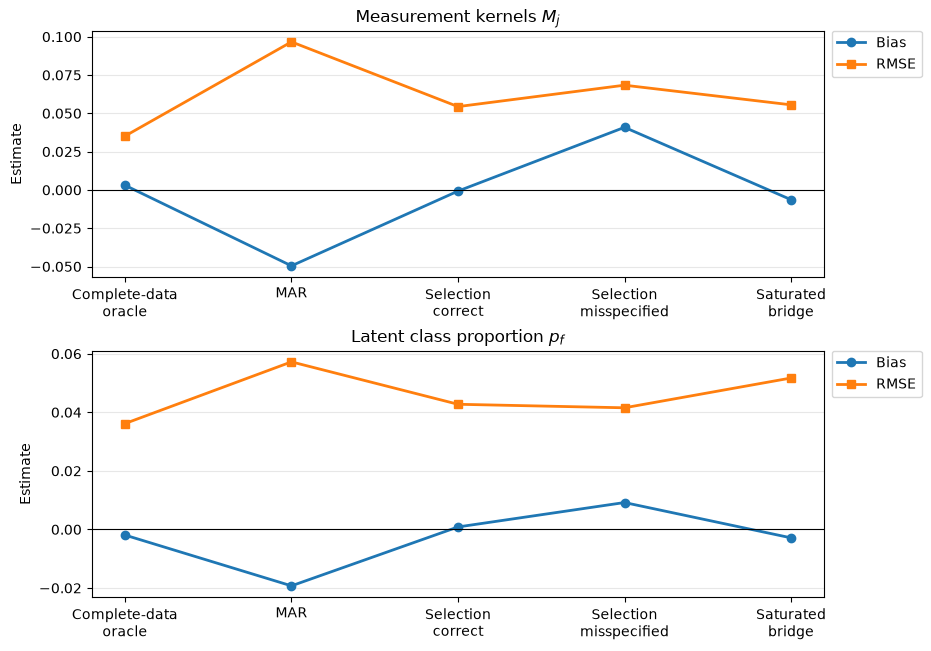

In [5]:
import matplotlib.pyplot as plt

method_order = [
    "full_data_oracle",
    "mar",
    "selection_likelihood_correct",
    "selection_likelihood_misspecified",
    "proposed_saturated_bridge",
]
method_labels = [
    "Complete-data\noracle",
    "MAR",
    "Selection\ncorrect",
    "Selection\nmisspecified",
    "Saturated\nbridge",
]
plot_data = summary.set_index("method").loc[method_order]
x = range(len(method_order))

fig, axes = plt.subplots(2, 1, figsize=(9.2, 6.4), constrained_layout=True)
panels = [
    ("Measurement kernels $M_j$", "M_bias", "M_RMSE"),
    ("Latent class proportion $p_f$", "p_f1_bias", "p_f1_RMSE"),
]
for axis, (title, bias_column, rmse_column) in zip(axes, panels):
    axis.plot(x, plot_data[bias_column], marker="o", linewidth=2, label="Bias")
    axis.plot(x, plot_data[rmse_column], marker="s", linewidth=2, label="RMSE")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_title(title)
    axis.set_ylabel("Estimate")
    axis.set_xticks(list(x), method_labels)
    axis.grid(axis="y", alpha=0.3)
    axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

figures_dir = ROOT / "simulation" / "figures"
figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / "allman_bias_rmse_comparison.pdf", bbox_inches="tight")
fig.savefig(figures_dir / "allman_bias_rmse_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## Recovery of the observed-variable law

There are three distinct targets.

1. **Overall outcome marginals:** $\mu_j=P(Y_j=1)$ for $j=2,3$. Each is a population full-data parameter recovered from a supported block at Stage 1.
2. **Supported-block laws:** $p_{S,c}=P(Y_S=c)$ for every cell $c\in\{00,01,10,11\}$. These are the direct Stage-1 identification targets.
3. **Full three-item joint law:** $P(Y_1,Y_2,Y_3)$. Because $Y_2$ and $Y_3$ need not be observed together, this law requires the Stage-2 latent decomposition and is reported separately.

For targets 1 and 2, we follow the reporting convention used by Zhao and Shao (2015): parameter-specific bias, empirical SD across Monte Carlo replications, mean estimated SE, and 95% Wald coverage. Estimated SEs are method-specific but account for first-stage estimation: likelihood methods use an observed-information sandwich and the proposed bridge uses a 200-replicate nonparametric bootstrap that re-estimates the bridge.

In [6]:
inference_method_order = [
    "full_data_oracle",
    "mar",
    "selection_likelihood_correct",
    "selection_likelihood_misspecified",
    "proposed_stage1_bridge",
]
observed_law_inference_summary.set_index(
    ["scope", "parameter", "method"]
).loc[
    [
        (scope, parameter, method)
        for scope, parameter in [
            ("overall_marginal", "mu_Y2"),
            ("overall_marginal", "mu_Y3"),
        ]
        for method in inference_method_order
    ]
].reset_index()[[
    "scope", "parameter", "method", "truth", "bias", "empirical_sd",
    "mean_estimated_se", "coverage",
]].round(4)

,scope,parameter,method,truth,bias,empirical_sd,mean_estimated_se,coverage
0,overall_marginal,mu_Y2,full_data_oracle,0.4750,0.0024,0.0246,0.0223,0.91
1,overall_marginal,mu_Y2,mar,0.4750,-0.0885,0.0313,0.0264,0.09
2,overall_marginal,mu_Y2,selection_likelihood_correct,0.4750,0.0005,0.0543,0.0494,0.86
3,overall_marginal,mu_Y2,selection_likelihood_misspecified,0.4750,0.0754,0.0240,0.0231,0.12
4,overall_marginal,mu_Y2,proposed_stage1_bridge,0.4750,-0.0099,0.0379,0.0365,0.94
5,overall_marginal,mu_Y3,full_data_oracle,0.4925,0.0021,0.0202,0.0223,0.97
6,overall_marginal,mu_Y3,mar,0.4925,-0.0762,0.0255,0.0266,0.13
7,overall_marginal,mu_Y3,selection_likelihood_correct,0.4925,-0.0018,0.0399,0.0420,0.94
8,overall_marginal,mu_Y3,selection_likelihood_misspecified,0.4925,0.0663,0.0204,0.0223,0.11
9,overall_marginal,mu_Y3,proposed_stage1_bridge,0.4925,-0.0096,0.0345,0.0339,0.93


### Parameter-specific observed-law inference\n\nThe proposed estimates are direct Stage-1 bridge estimates. The other methods report the same target laws implied by their fitted models; they must not all be described as Stage-1 estimators. The first figure evaluates population marginals recovered from supported blocks. The second expands the same four criteria to all eight supported-block cell probabilities. A calibrated SE should track empirical SD, and pointwise 95% coverage should lie near the horizontal 0.95 reference line.

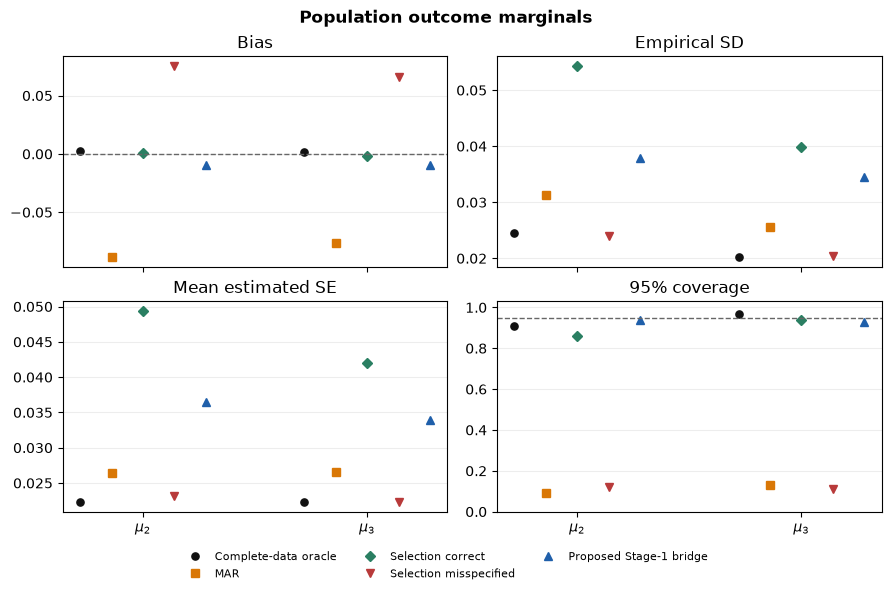

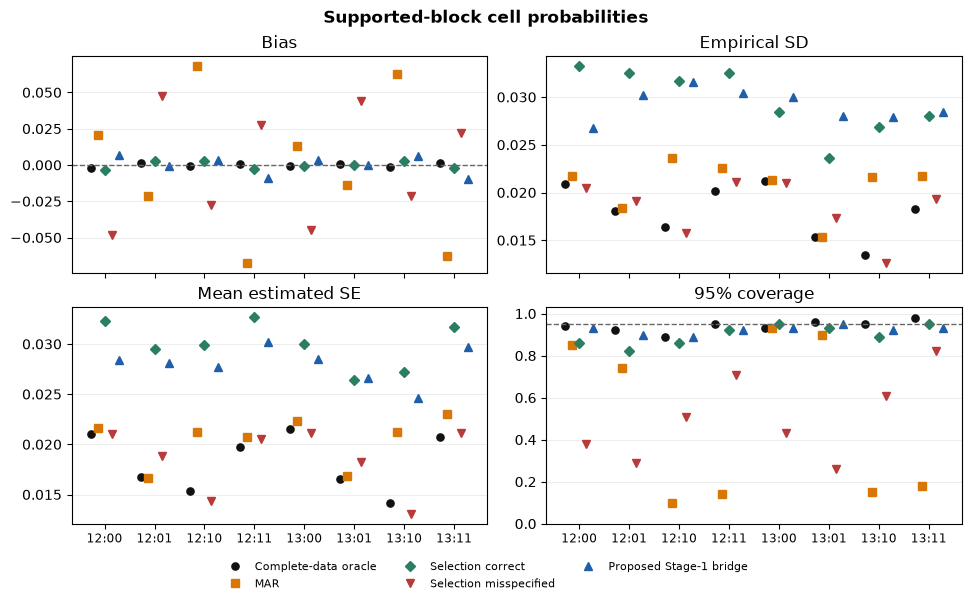

In [7]:
import matplotlib.pyplot as plt

inference_labels = {
    "full_data_oracle": "Complete-data oracle",
    "mar": "MAR",
    "selection_likelihood_correct": "Selection correct",
    "selection_likelihood_misspecified": "Selection misspecified",
    "proposed_stage1_bridge": "Proposed Stage-1 bridge",
}
inference_colors = {
    "full_data_oracle": "#111111",
    "mar": "#D97706",
    "selection_likelihood_correct": "#2A7F62",
    "selection_likelihood_misspecified": "#B83A3A",
    "proposed_stage1_bridge": "#1F5FAA",
}
inference_markers = {
    "full_data_oracle": "o",
    "mar": "s",
    "selection_likelihood_correct": "D",
    "selection_likelihood_misspecified": "v",
    "proposed_stage1_bridge": "^",
}
metric_specification = [
    ("bias", "Bias", 0.0),
    ("empirical_sd", "Empirical SD", None),
    ("mean_estimated_se", "Mean estimated SE", None),
    ("coverage", "95% coverage", 0.95),
]
figures_dir = ROOT / "simulation" / "figures"
figures_dir.mkdir(exist_ok=True)


def plot_inference(
    scope, parameter_labels, title, output_stem, figsize, legend_columns=3,
    tick_rotation=0, tick_fontsize=None,
):
    panel = observed_law_inference_summary[
        observed_law_inference_summary["scope"] == scope
    ].copy()
    parameters = (
        panel[["parameter_index", "parameter"]]
        .drop_duplicates()
        .sort_values("parameter_index")["parameter"]
        .tolist()
    )
    method_offset = dict(
        zip(inference_method_order, [-0.28, -0.14, 0.0, 0.14, 0.28])
    )
    figure, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.ravel()
    for panel_index, (axis, (metric, label, reference)) in enumerate(
        zip(axes, metric_specification)
    ):
        for method in inference_method_order:
            values = (
                panel[panel["method"] == method]
                .set_index("parameter")
                .loc[parameters]
                .reset_index()
            )
            axis.plot(
                [
                    index + method_offset[method]
                    for index in range(len(parameters))
                ],
                values[metric],
                color=inference_colors[method],
                marker=inference_markers[method],
                linestyle="none",
                markersize=5.2,
                label=inference_labels[method],
            )
        if reference is not None:
            axis.axhline(
                reference, color="#666666", linewidth=1.0, linestyle="--"
            )
        axis.set_title(label)
        axis.set_xticks(
            range(len(parameters)),
            [parameter_labels[p] for p in parameters],
            rotation=tick_rotation,
            ha="right" if tick_rotation else "center",
        )
        if tick_fontsize is not None:
            axis.tick_params(axis="x", labelsize=tick_fontsize)
        if panel_index < 2:
            axis.tick_params(axis="x", labelbottom=False)
        axis.grid(axis="y", alpha=0.22)
        if metric == "coverage":
            axis.set_ylim(0.0, 1.03)
    figure.suptitle(title, fontsize=12, fontweight="bold")
    handles, labels = axes[0].get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc="outside lower center",
        ncol=legend_columns,
        frameon=False,
        fontsize=8,
    )
    figure.savefig(figures_dir / f"{output_stem}.pdf", bbox_inches="tight")
    figure.savefig(
        figures_dir / f"{output_stem}.png", dpi=180, bbox_inches="tight"
    )
    return figure


marginal_labels = {"mu_Y2": r"$\mu_2$", "mu_Y3": r"$\mu_3$"}
fig_marginal = plot_inference(
    "overall_marginal",
    marginal_labels,
    "Population outcome marginals",
    "allman_outcome_marginal_inference",
    (8.8, 5.8),
)
plt.show()
fig_marginal_column = plot_inference(
    "overall_marginal",
    marginal_labels,
    "Population outcome marginals",
    "allman_outcome_marginal_inference_column",
    (4.8, 5.9),
    legend_columns=2,
)
plt.close(fig_marginal_column)

block_labels = {
    f"S{anchor}{item}_p{y_anchor}{y_item}":
        rf"$S_{{{anchor}{item}}}$" + "\n" + f"{y_anchor}{y_item}"
    for anchor, item in ((1, 2), (1, 3))
    for y_anchor in (0, 1)
    for y_item in (0, 1)
}
block_labels_column = {key: key.replace("_p", ":") for key in block_labels}
block_labels_wide = {
    key: key.removeprefix("S").replace("_p", ":") for key in block_labels
}
fig_block = plot_inference(
    "supported_block",
    block_labels_wide,
    "Supported-block cell probabilities",
    "allman_supported_block_inference",
    (9.6, 5.9),
    tick_fontsize=8.5,
)
plt.show()
fig_block_column = plot_inference(
    "supported_block",
    block_labels_column,
    "Supported-block cell probabilities",
    "allman_supported_block_inference_column",
    (5.2, 6.2),
    legend_columns=2,
    tick_rotation=90,
    tick_fontsize=7.5,
)
plt.close(fig_block_column)

### Stage-2 full joint-law diagnostic

The full $P(Y_1,Y_2,Y_3)$ is reconstructed from each latent fit. Unlike the marginal and supported-block results above, the proposed estimator here includes Stage 2. Total variation remains a compact supplementary measure of all eight joint-cell errors.

In [8]:
model = config["model"]
true_class_probability = pd.Series(model["class_probability"], dtype=float).to_numpy()
true_measurement = pd.DataFrame(
    [model["bernoulli_probability"][name] for name in ("Y1", "Y2", "Y3")],
    dtype=float,
).to_numpy()
y_cells, true_joint_probability = binary_product_mixture_joint(
    true_class_probability, true_measurement
)
cell_labels_joint = ["".join(str(value) for value in cell) for cell in y_cells]

joint_records = []
for cell_label, probability in zip(cell_labels_joint, true_joint_probability):
    joint_records.append({
        "replication": -1,
        "method": "population_truth",
        "cell": cell_label,
        "probability": probability,
        "truth": probability,
        "error": 0.0,
    })

for _, row in replication_results.iterrows():
    fitted_class_probability = pd.Series(
        [1.0 - row["p_f1_estimate"], row["p_f1_estimate"]], dtype=float
    ).to_numpy()
    fitted_measurement = pd.DataFrame(
        [
            [row[f"M_estimate_Y{item}_f{latent}"] for latent in (0, 1)]
            for item in (1, 2, 3)
        ],
        dtype=float,
    ).to_numpy()
    cells, fitted_probability = binary_product_mixture_joint(
        fitted_class_probability, fitted_measurement
    )
    assert (cells == y_cells).all()
    for cell_label, probability, truth in zip(
        cell_labels_joint, fitted_probability, true_joint_probability
    ):
        joint_records.append({
            "replication": int(row["replication"]),
            "method": row["method"],
            "cell": cell_label,
            "probability": probability,
            "truth": truth,
            "error": probability - truth,
        })

joint_distribution = pd.DataFrame(joint_records)
fitted_joint = joint_distribution[joint_distribution["method"] != "population_truth"]
joint_tv = (
    fitted_joint.assign(absolute_error=lambda frame: frame["error"].abs())
    .groupby(["replication", "method"], as_index=False)["absolute_error"]
    .sum()
    .assign(total_variation=lambda frame: 0.5 * frame["absolute_error"])
)
joint_tv_summary = (
    joint_tv.groupby("method", as_index=False)
    .agg(
        mean_total_variation=("total_variation", "mean"),
        median_total_variation=("total_variation", "median"),
        sd_total_variation=("total_variation", "std"),
    )
)

# The reconstructed joint law must reproduce every fitted marginal probability.
for _, row in replication_results.iterrows():
    distribution = fitted_joint[
        (fitted_joint["replication"] == int(row["replication"]))
        & (fitted_joint["method"] == row["method"])
    ].sort_values("cell")
    for item in (1, 2, 3):
        marginal = distribution.loc[
            distribution["cell"].str[item - 1] == "1", "probability"
        ].sum()
        assert abs(marginal - row[f"Y_mean_estimate_Y{item}"]) < 1e-10

joint_distribution.to_csv(results_dir / "allman_y_joint_distribution.csv", index=False)
joint_tv_summary.to_csv(results_dir / "allman_y_joint_tv_summary.csv", index=False)
joint_tv_summary.set_index("method").loc[config["estimation"]["methods"]].reset_index().round(5)

,method,mean_total_variation,median_total_variation,sd_total_variation
0,full_data_oracle,0.04061,0.03996,0.01360
1,mar,0.11713,0.11407,0.02303
2,selection_likelihood_correct,0.06961,0.06626,0.02718
3,selection_likelihood_misspecified,0.10055,0.09994,0.01657
4,proposed_saturated_bridge,0.06507,0.06213,0.02056


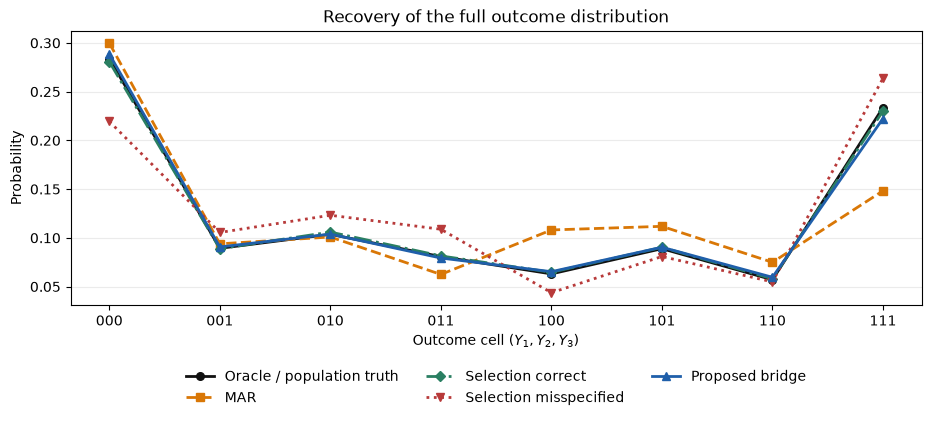

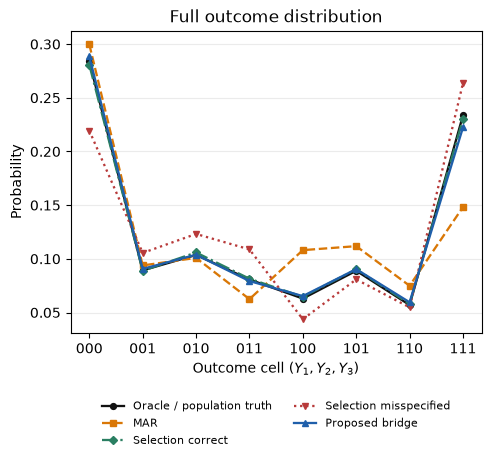

In [9]:
joint_plot_data = (
    joint_distribution.groupby(["method", "cell"], as_index=False)["probability"]
    .mean()
)
plot_methods = [
    "population_truth",
    "mar",
    "selection_likelihood_correct",
    "selection_likelihood_misspecified",
    "proposed_saturated_bridge",
]
plot_labels = {
    "population_truth": "Oracle / population truth",
    "mar": "MAR",
    "selection_likelihood_correct": "Selection correct",
    "selection_likelihood_misspecified": "Selection misspecified",
    "proposed_saturated_bridge": "Proposed bridge",
}
plot_colors = {
    "population_truth": "#111111",
    "mar": "#D97706",
    "selection_likelihood_correct": "#2A7F62",
    "selection_likelihood_misspecified": "#B83A3A",
    "proposed_saturated_bridge": "#1F5FAA",
}
plot_markers = {
    "population_truth": "o",
    "mar": "s",
    "selection_likelihood_correct": "D",
    "selection_likelihood_misspecified": "v",
    "proposed_saturated_bridge": "^",
}
plot_linestyles = {
    "population_truth": "-",
    "mar": "--",
    "selection_likelihood_correct": "-.",
    "selection_likelihood_misspecified": ":",
    "proposed_saturated_bridge": "-",
}

fig, axis = plt.subplots(figsize=(9.2, 4.1), constrained_layout=True)
for method in plot_methods:
    values = (
        joint_plot_data[joint_plot_data["method"] == method]
        .set_index("cell")
        .loc[cell_labels_joint]
        .reset_index()
    )
    axis.plot(
        range(len(cell_labels_joint)), values["probability"],
        color=plot_colors[method], marker=plot_markers[method],
        linestyle=plot_linestyles[method], linewidth=2.0, markersize=5.5,
        label=plot_labels[method],
    )
axis.set_title("Recovery of the full outcome distribution")
axis.set_xlabel("Outcome cell $(Y_1,Y_2,Y_3)$")
axis.set_ylabel("Probability")
axis.set_xticks(range(len(cell_labels_joint)), cell_labels_joint)
axis.grid(axis="y", alpha=0.25)
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.19), ncol=3, frameon=False)
fig.savefig(figures_dir / "allman_y_joint_distribution_recovery.pdf", bbox_inches="tight")
fig.savefig(figures_dir / "allman_y_joint_distribution_recovery.png", dpi=180, bbox_inches="tight")
plt.show()

fig_column, axis_column = plt.subplots(figsize=(4.8, 4.5), constrained_layout=True)
for method in plot_methods:
    values = (
        joint_plot_data[joint_plot_data["method"] == method]
        .set_index("cell")
        .loc[cell_labels_joint]
        .reset_index()
    )
    axis_column.plot(
        range(len(cell_labels_joint)), values["probability"],
        color=plot_colors[method], marker=plot_markers[method],
        linestyle=plot_linestyles[method], linewidth=1.65, markersize=4.2,
        label=plot_labels[method],
    )
axis_column.set_title("Full outcome distribution")
axis_column.set_xlabel("Outcome cell $(Y_1,Y_2,Y_3)$")
axis_column.set_ylabel("Probability")
axis_column.set_xticks(range(len(cell_labels_joint)), cell_labels_joint)
axis_column.grid(axis="y", alpha=0.25)
axis_column.legend(loc="upper center", bbox_to_anchor=(0.5, -0.19), ncol=2, frameon=False, fontsize=8)
fig_column.savefig(figures_dir / "allman_y_joint_distribution_recovery_column.pdf", bbox_inches="tight")
fig_column.savefig(figures_dir / "allman_y_joint_distribution_recovery_column.png", dpi=180, bbox_inches="tight")
plt.show()

### Direct Stage-1 supported-pair diagnostic

The next figure isolates the first stage before latent decomposition. It compares the respondent-only pair law with the normalized-IPW bridge recovery for each supported pair.

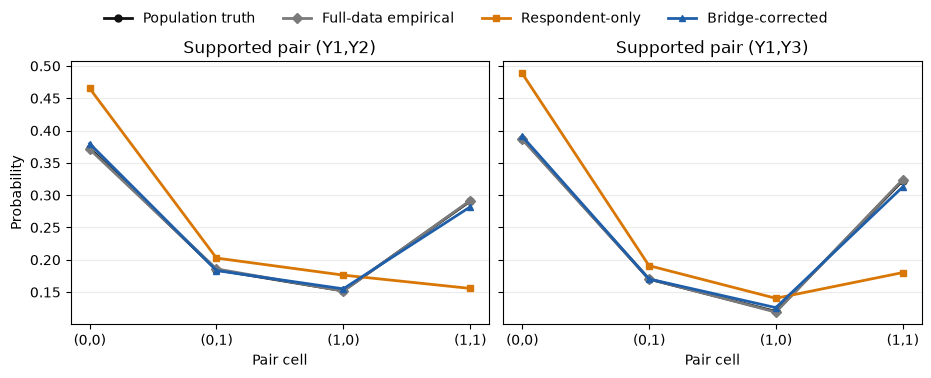

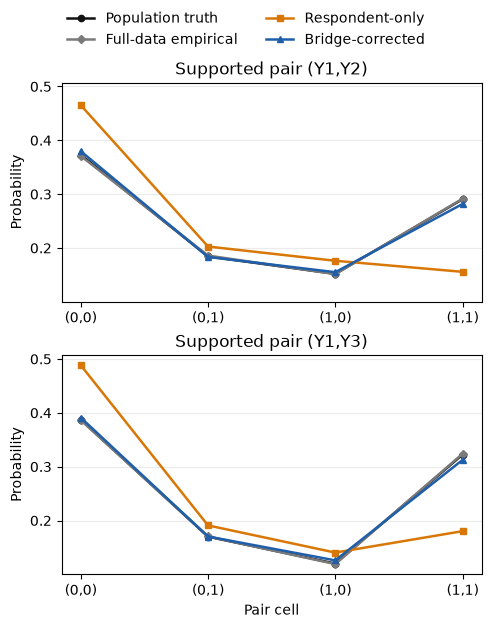

In [10]:
pair_plot = (
    y_pair_distribution
    .groupby(["pair", "method", "cell"], as_index=False)["probability"]
    .mean()
)
distribution_methods = [
    "population_truth",
    "full_data_empirical",
    "respondent_only",
    "proposed_stage1_bridge",
]
distribution_labels = {
    "population_truth": "Population truth",
    "full_data_empirical": "Full-data empirical",
    "respondent_only": "Respondent-only",
    "proposed_stage1_bridge": "Bridge-corrected",
}
colors = {
    "population_truth": "#111111",
    "full_data_empirical": "#7A7A7A",
    "respondent_only": "#D97706",
    "proposed_stage1_bridge": "#1F5FAA",
}
markers = {
    "population_truth": "o",
    "full_data_empirical": "D",
    "respondent_only": "s",
    "proposed_stage1_bridge": "^",
}

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7), sharey=True, constrained_layout=True)
cell_labels = ["(0,0)", "(0,1)", "(1,0)", "(1,1)"]
for axis, pair in zip(axes, ["Y1,Y2", "Y1,Y3"]):
    panel = pair_plot[pair_plot["pair"] == pair]
    for method in distribution_methods:
        values = panel[panel["method"] == method].sort_values("cell")
        axis.plot(
            values["cell"], values["probability"],
            color=colors[method], marker=markers[method], linewidth=2,
            markersize=5, label=distribution_labels[method],
        )
    axis.set_title(f"Supported pair ({pair})")
    axis.set_xlabel("Pair cell")
    axis.set_xticks(range(4), cell_labels)
    axis.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Probability")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside upper center", ncol=4, frameon=False)
figures_dir = ROOT / "simulation" / "figures"
figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / "allman_y_distribution_recovery.pdf", bbox_inches="tight")
fig.savefig(figures_dir / "allman_y_distribution_recovery.png", dpi=180, bbox_inches="tight")
plt.show()

fig_column, axes_column = plt.subplots(2, 1, figsize=(4.8, 6.2), sharey=True, constrained_layout=True)
for axis, pair in zip(axes_column, ["Y1,Y2", "Y1,Y3"]):
    panel = pair_plot[pair_plot["pair"] == pair]
    for method in distribution_methods:
        values = panel[panel["method"] == method].sort_values("cell")
        axis.plot(
            values["cell"], values["probability"],
            color=colors[method], marker=markers[method], linewidth=1.8,
            markersize=4.5, label=distribution_labels[method],
        )
    axis.set_title(f"Supported pair ({pair})")
    axis.set_xticks(range(4), cell_labels)
    axis.grid(axis="y", alpha=0.25)
axes_column[0].set_ylabel("Probability")
axes_column[1].set_ylabel("Probability")
axes_column[1].set_xlabel("Pair cell")
handles, labels = axes_column[0].get_legend_handles_labels()
fig_column.legend(handles, labels, loc="outside upper center", ncol=2, frameon=False)
fig_column.savefig(figures_dir / "allman_y_distribution_recovery_column.pdf", bbox_inches="tight")
fig_column.savefig(figures_dir / "allman_y_distribution_recovery_column.png", dpi=180, bbox_inches="tight")
plt.show()

## Supporting diagnostics

These quantities verify the design but are not intended as headline results.

In [11]:
overlap[[
    "item_observation_rate", "anchor_pair_rate", "extension_pair_rate",
    "complete_case_rate", "minimum_true_pair_propensity"
]].mean().round(4)

item_observation_rate           0.8005
anchor_pair_rate                0.7001
extension_pair_rate             0.7015
complete_case_rate              0.5228
minimum_true_pair_propensity    0.3715
dtype: float64

In [12]:
bridge_diagnostics.groupby("block").agg(
    minimum_design_rank=("design_rank", "min"),
    minimum_singular_value=("minimum_singular_value", "min"),
    median_condition_number=("condition_number", "median"),
    maximum_condition_number=("condition_number", "max"),
    mean_maximum_absolute_moment=("maximum_absolute_moment", "mean"),
    minimum_instrument_cell_count=("minimum_instrument_cell_count", "min"),
    lower_constraint_activation_rate=("lower_constraint_count", lambda x: (x > 0).mean()),
    upper_constraint_activation_rate=("upper_constraint_count", lambda x: (x > 0).mean()),
    mean_effective_sample_size=("effective_sample_size", "mean"),
).round(4)

,minimum_design_rank,minimum_singular_value,median_condition_number,maximum_condition_number,mean_maximum_absolute_moment,minimum_instrument_cell_count,lower_constraint_activation_rate,upper_constraint_activation_rate,mean_effective_sample_size
block,,,,,,,,,
0,4,0.2163,3.4578,5.2783,0.1448,29,0.22,0.0,308.8164
1,4,0.2212,3.5007,5.7096,0.1358,27,0.18,0.0,309.7741


## Interpretation

The parameter-specific figures are the headline observed-law checks. They distinguish systematic error (bias), repeated-sample dispersion (empirical SD), the method's own uncertainty estimate (mean SE), and interval calibration (95% coverage). The proposed outcome-law estimate is the direct supported-block bridge before latent decomposition; the other four laws are implied by their corresponding fitted models.

The full joint-law comparison is secondary because it necessarily adds Stage 2. It checks whether the subsequent latent decomposition connects the recovered overlapping block laws into a coherent $P(Y_1,Y_2,Y_3)$.

For the latent targets, the original five-model comparison remains relevant. MAR confounds MNAR selection with the measurement kernels, while the correctly specified selection likelihood and the bridge-weighted latent fit recover the measurement kernels more accurately. The robustness comparison is limited to parametric selection-link misspecification: the bridge still relies on shadow-IV exclusion, positivity, B-completeness, and the finite latent-class measurement model.